# Day 38/60 — Analyzing Customer Retention and Lifetime Value

## Customer Retention Analytics

Analyzing customer retention, Customer Lifetime Value (CLV), and high-value
customer groups using historical customer and sales data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 38 libraries imported successfully!")

Day 38 libraries imported successfully!


In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Customer sales dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Customer sales dataset loaded successfully!
Dataset shape: (51290, 23)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])

print("Order date converted successfully!")

print("\nDate range:")
print(df["order_date"].min(), "to", df["order_date"].max())

display(df[["customer_name", "order_date", "sales"]].head())

Order date converted successfully!

Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00


,customer_name,order_date,sales
0,Toby Braunhardt,2011-01-01,408.0
1,Joseph Holt,2011-01-01,120.0
2,Annie Thurman,2011-01-01,66.0
3,Eugene Moren,2011-01-01,45.0
4,Joseph Holt,2011-01-01,114.0


In [4]:
customer_metrics = df.groupby("customer_name").agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    number_of_orders=("order_id", "nunique"),
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max")
).reset_index()

print("Customer-level metrics created successfully!")

print("\nNumber of customers:", len(customer_metrics))

display(customer_metrics.head(10))

Customer-level metrics created successfully!

Number of customers: 795


,customer_name,total_revenue,total_profit,number_of_orders,first_purchase,last_purchase
0,Aaron Bergman,24646.0,4683.20800,37,2011-02-19,2014-12-15
1,Aaron Hawkins,20759.0,2450.92904,34,2011-04-22,2014-12-19
2,Aaron Smayling,14207.0,369.16180,31,2011-03-21,2014-12-08
3,Adam Bellavance,20189.0,4979.97690,41,2011-01-07,2014-11-26
4,Adam Hart,21720.0,1902.03342,42,2011-06-10,2014-12-29
5,Adam Shillingsburg,15445.0,1421.27412,36,2011-04-06,2014-12-16
6,Adrian Barton,25125.0,6417.28450,40,2011-05-18,2014-12-04
7,Adrian Hane,11406.0,2081.37928,26,2011-07-18,2014-12-10
8,Adrian Shami,11287.0,1564.49380,24,2011-11-17,2014-11-20
9,Aimee Bixby,16205.0,2926.35430,28,2011-01-25,2014-11-26


In [5]:
average_orders = customer_metrics["number_of_orders"].mean()

print("Customer purchase frequency calculated successfully!")

print("\nAverage orders per customer:")
print(round(average_orders, 2))

Customer purchase frequency calculated successfully!

Average orders per customer:
32.39


In [6]:
customer_metrics["customer_type"] = np.where(
    customer_metrics["number_of_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_type_counts = (
    customer_metrics["customer_type"]
    .value_counts()
)

print("Customer repeat-purchase analysis completed!")

display(customer_type_counts)

Customer repeat-purchase analysis completed!


customer_type
Repeat Customer    795
Name: count, dtype: int64

In [7]:
total_customers = len(customer_metrics)

repeat_customers = (
    customer_metrics["customer_type"] == "Repeat Customer"
).sum()

retention_rate = (
    repeat_customers / total_customers
) * 100

print("Customer retention rate calculated successfully!")

print("\nTotal customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Retention rate:", round(retention_rate, 2), "%")

Customer retention rate calculated successfully!

Total customers: 795
Repeat customers: 795
Retention rate: 100.0 %


In [8]:
average_revenue_per_order = (
    customer_metrics["total_revenue"]
    / customer_metrics["number_of_orders"]
).mean()

average_orders_per_customer = (
    customer_metrics["number_of_orders"].mean()
)

estimated_clv = (
    average_revenue_per_order
    * average_orders_per_customer
)

print("Customer Lifetime Value calculated successfully!")

print("\nAverage revenue per order:")
print(round(average_revenue_per_order, 2))

print("\nAverage orders per customer:")
print(round(average_orders_per_customer, 2))

print("\nEstimated Customer Lifetime Value:")
print(round(estimated_clv, 2))

Customer Lifetime Value calculated successfully!

Average revenue per order:
491.04

Average orders per customer:
32.39

Estimated Customer Lifetime Value:
15906.53


In [9]:
revenue_threshold = customer_metrics["total_revenue"].median()

customer_metrics["value_group"] = np.where(
    customer_metrics["total_revenue"] >= revenue_threshold,
    "High-Value Customer",
    "Regular-Value Customer"
)

value_group_counts = (
    customer_metrics["value_group"]
    .value_counts()
)

print("Customer value groups created successfully!")

print("\nRevenue threshold:")
print(round(revenue_threshold, 2))

print("\nCustomer groups:")
display(value_group_counts)

Customer value groups created successfully!

Revenue threshold:
15258.0

Customer groups:


value_group
High-Value Customer       398
Regular-Value Customer    397
Name: count, dtype: int64

In [10]:
value_group_summary = (
    customer_metrics
    .groupby("value_group")
    .agg(
        customer_count=("customer_name", "count"),
        total_revenue=("total_revenue", "sum"),
        average_revenue=("total_revenue", "mean"),
        average_orders=("number_of_orders", "mean")
    )
    .reset_index()
)

print("Customer value group analysis completed!")

display(value_group_summary)

Customer value group analysis completed!


,value_group,customer_count,total_revenue,average_revenue,average_orders
0,High-Value Customer,398,7917061.0,19892.113065,34.791457
1,Regular-Value Customer,397,4725844.0,11903.889169,29.989924


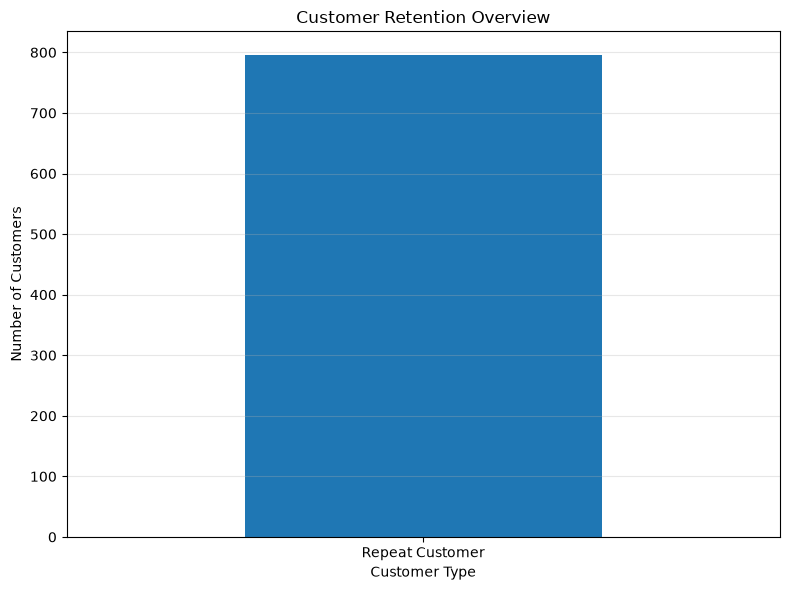

Customer retention visualization created successfully!


In [11]:
# Visualize customer retention

plt.figure(figsize=(8, 6))

customer_type_counts.plot(
    kind="bar"
)

plt.title("Customer Retention Overview")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("Customer retention visualization created successfully!")


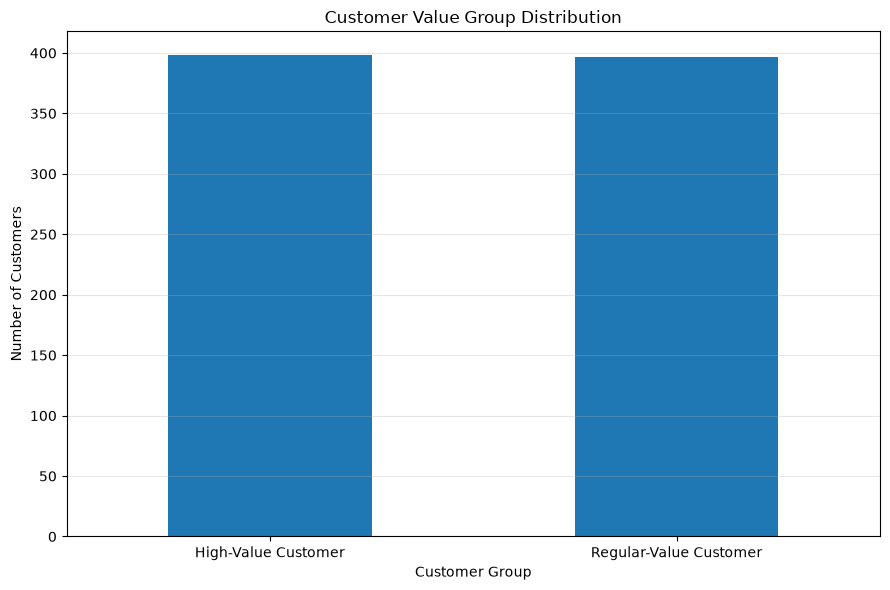

Customer value group visualization created successfully!


In [12]:
# Visualize customer value groups

plt.figure(figsize=(9, 6))

value_group_counts.plot(
    kind="bar"
)

plt.title("Customer Value Group Distribution")
plt.xlabel("Customer Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("Customer value group visualization created successfully!")

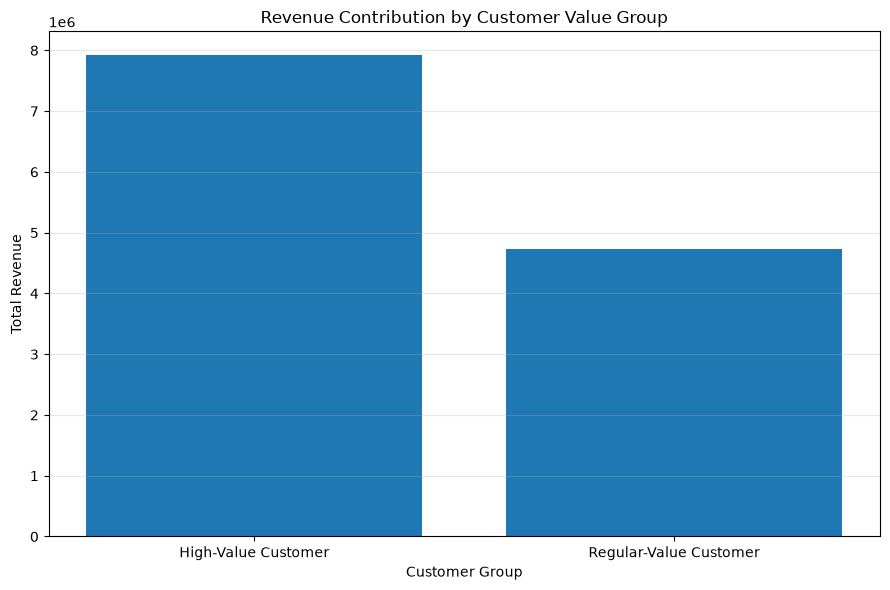

Revenue contribution visualization created successfully!


In [13]:
# Compare revenue contribution by customer group

plt.figure(figsize=(9, 6))

plt.bar(
    value_group_summary["value_group"],
    value_group_summary["total_revenue"]
)

plt.title("Revenue Contribution by Customer Value Group")
plt.xlabel("Customer Group")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("Revenue contribution visualization created successfully!")

In [14]:
# Create yearly customer retention data

df["year"] = df["order_date"].dt.year

yearly_customer_orders = (
    df.groupby(["year", "customer_name"])["order_id"]
    .nunique()
    .reset_index()
)

yearly_customer_orders["customer_type"] = np.where(
    yearly_customer_orders["order_id"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

yearly_retention = (
    yearly_customer_orders
    .groupby(["year", "customer_type"])["customer_name"]
    .nunique()
    .unstack(fill_value=0)
)

yearly_retention["retention_rate"] = (
    yearly_retention.get("Repeat Customer", 0)
    /
    yearly_retention.sum(axis=1)
) * 100

print("Yearly retention trend calculated successfully!")

display(yearly_retention)

Yearly retention trend calculated successfully!


customer_type,One-Time Customer,Repeat Customer,retention_rate
year,,,
2011,12,783,98.490566
2012,5,790,99.371069
2013,0,795,100.000000
2014,0,794,100.000000


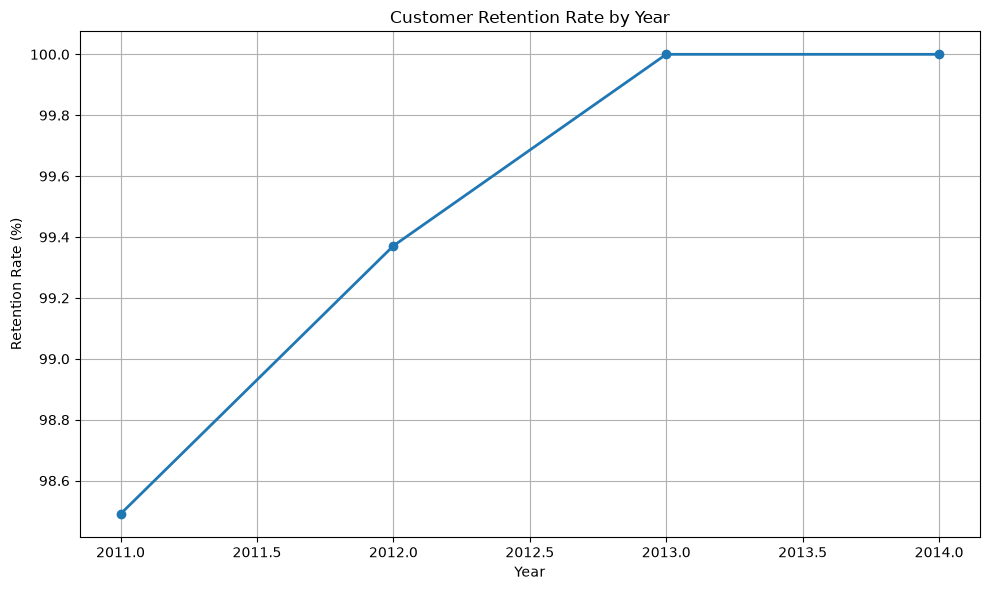

Yearly retention trend visualized successfully!


In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_retention.index,
    yearly_retention["retention_rate"],
    marker="o",
    linewidth=2
)

plt.title("Customer Retention Rate by Year")
plt.xlabel("Year")
plt.ylabel("Retention Rate (%)")

plt.grid(True)

plt.tight_layout()

plt.show()

print("Yearly retention trend visualized successfully!")

In [16]:
customer_metrics["customer_clv"] = (
    customer_metrics["total_revenue"]
    / customer_metrics["number_of_orders"]
) * customer_metrics["number_of_orders"]

print("Individual customer CLV calculated successfully!")

display(
    customer_metrics[
        [
            "customer_name",
            "total_revenue",
            "number_of_orders",
            "customer_clv"
        ]
    ].head(10)
)

Individual customer CLV calculated successfully!


,customer_name,total_revenue,number_of_orders,customer_clv
0,Aaron Bergman,24646.0,37,24646.0
1,Aaron Hawkins,20759.0,34,20759.0
2,Aaron Smayling,14207.0,31,14207.0
3,Adam Bellavance,20189.0,41,20189.0
4,Adam Hart,21720.0,42,21720.0
5,Adam Shillingsburg,15445.0,36,15445.0
6,Adrian Barton,25125.0,40,25125.0
7,Adrian Hane,11406.0,26,11406.0
8,Adrian Shami,11287.0,24,11287.0
9,Aimee Bixby,16205.0,28,16205.0


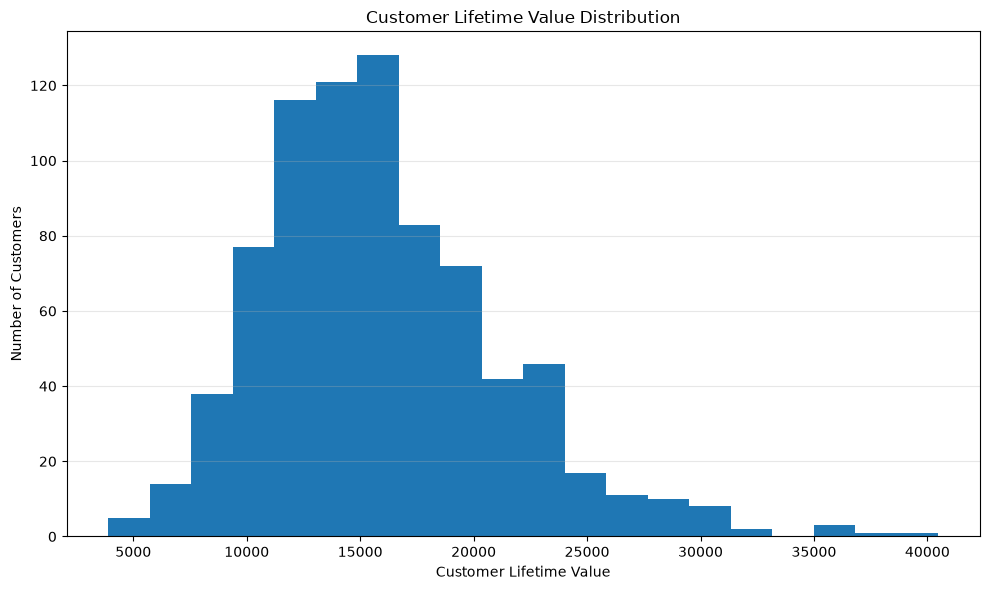

Customer Lifetime Value distribution visualized successfully!


In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_metrics["customer_clv"],
    bins=20
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Customer Lifetime Value")
plt.ylabel("Number of Customers")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("Customer Lifetime Value distribution visualized successfully!")

In [18]:
customer_metrics.to_csv(
    "customer_clv_retention_analysis.csv",
    index=False
)

yearly_retention.reset_index().to_csv(
    "yearly_retention_analysis.csv",
    index=False
)

value_group_summary.to_csv(
    "customer_value_group_summary.csv",
    index=False
)

print("Day 38 analysis files saved successfully!")

print("\nCreated files:")
print("✓ customer_clv_retention_analysis.csv")
print("✓ yearly_retention_analysis.csv")
print("✓ customer_value_group_summary.csv")

Day 38 analysis files saved successfully!

Created files:
✓ customer_clv_retention_analysis.csv
✓ yearly_retention_analysis.csv
✓ customer_value_group_summary.csv


In [19]:
visualization_report = f"""
# Day 38 — Customer Retention and Lifetime Value Report

## Customer Retention

Total customers analyzed: {total_customers}

Repeat customers: {repeat_customers}

Repeat-purchase retention rate: {retention_rate:.2f}%

The retention metric used in this project identifies customers who placed
more than one order during the available historical period.

## Customer Lifetime Value

Average revenue per order: {average_revenue_per_order:.2f}

Average orders per customer: {average_orders_per_customer:.2f}

Estimated average Customer Lifetime Value: {estimated_clv:.2f}

The CLV estimate is based on historical customer purchasing behavior.

## Customer Value Groups

Customers were divided into High-Value Customers and Regular-Value Customers
using the median customer revenue as the threshold.

High-value customers are customers whose historical revenue is at or above
the median customer revenue.

## Visualizations Created

The analysis includes:

1. Customer Retention Overview
2. Customer Value Group Distribution
3. Revenue Contribution by Customer Value Group
4. Customer Retention Rate by Year
5. Customer Lifetime Value Distribution

## Business Implications

Customer retention analysis helps businesses understand repeat purchasing
behavior and identify customers who generate higher historical revenue.

High-value customers can be considered for retention activities such as:

- Personalized offers
- Loyalty programs
- Product recommendations
- Priority customer support
- Repeat-purchase campaigns

## Important Limitation

The retention metric in this project is a simple repeat-purchase measure.
It is not a formal cohort retention calculation.

The CLV calculation is also a historical estimate and does not predict
future customer spending.

Future improvements could include:

- Cohort retention analysis
- Purchase-frequency modeling
- Predictive CLV
- Customer churn analysis
- Profit-based CLV
- Discounted cash-flow CLV

## Conclusion

This analysis demonstrates how customer purchasing behavior can be used to
measure retention and estimate customer value.

Understanding retention and lifetime value can help businesses make more
informed decisions about customer engagement and long-term revenue.
"""

with open("retention_visualization_report.md", "w", encoding="utf-8") as file:
    file.write(visualization_report)

print("Visualization report created successfully!")
print("File: retention_visualization_report.md")

Visualization report created successfully!
File: retention_visualization_report.md


In [20]:
import os

day38_files = os.listdir(".")

print("Day 38 files:")
for file in day38_files:
    print("✓", file)

Day 38 files:
✓ customer_clv_retention_analysis.csv
✓ customer_value_group_summary.csv
✓ day38.ipynb
✓ README.md
✓ retention_visualization_report.md
✓ yearly_retention_analysis.csv
